# Financial Ratios

Financial ratios turn raw financial statements into comparable signals. They help analysts understand profitability, efficiency, liquidity, leverage, growth, and valuation before building a detailed model.

Abbreviations used in this notebook:

- **ROE**: Return on Equity.
- **ROA**: Return on Assets.
- **ROIC**: Return on Invested Capital.
- **EBIT**: Earnings Before Interest and Taxes.
- **EBITDA**: Earnings Before Interest, Taxes, Depreciation, and Amortization.

## 1. Intuition

Ratios make companies easier to compare. A company with CHF 10bn of revenue is not automatically better than a company with CHF 1bn of revenue; margins, returns on capital, leverage, and growth determine the quality of that revenue.

Common ratio families:

- **Profitability**: how much profit the company earns from revenue, assets, or equity.
- **Efficiency**: how effectively the company uses assets and working capital.
- **Liquidity**: whether the company can meet near-term obligations.
- **Leverage**: how much debt supports the business.
- **Growth**: how quickly sales, earnings, or cash flow are increasing.
- **Valuation**: how the market price compares with fundamentals.

## 2. Mathematics

**Gross margin:**

$$
\text{Gross Margin} = \frac{\text{Revenue} - \text{Cost of Goods Sold}}{\text{Revenue}}
$$

Where:

- $\text{Revenue}$ = sales generated during the period
- $\text{Cost of Goods Sold}$ = direct costs required to produce or purchase the goods sold
- $\text{Gross Margin}$ = percentage of revenue left after direct production costs

**Operating margin:**

$$
\text{Operating Margin} = \frac{EBIT}{\text{Revenue}}
$$

Where:

- $EBIT$ = earnings before interest and taxes
- $\text{Revenue}$ = sales generated during the period
- $\text{Operating Margin}$ = operating profit as a percentage of revenue

**Net margin:**

$$
\text{Net Margin} = \frac{\text{Net Income}}{\text{Revenue}}
$$

Where:

- $\text{Net Income}$ = profit after operating costs, interest, taxes, and other items
- $\text{Revenue}$ = sales generated during the period
- $\text{Net Margin}$ = final profit as a percentage of revenue

**Return on equity:**

$$
ROE = \frac{\text{Net Income}}{\text{Average Equity}}
$$

Where:

- $ROE$ = return on equity
- $\text{Net Income}$ = profit attributable to shareholders
- $\text{Average Equity}$ = average book value of shareholders' equity during the period

**Return on invested capital:**

$$
ROIC = \frac{NOPAT}{\text{Invested Capital}}
$$

Where:

- $ROIC$ = return on invested capital
- $NOPAT$ = net operating profit after tax
- $\text{Invested Capital}$ = operating capital funded by debt and equity investors

**Current ratio:**

$$
\text{Current Ratio} = \frac{\text{Current Assets}}{\text{Current Liabilities}}
$$

Where:

- $\text{Current Assets}$ = assets expected to convert to cash within one year
- $\text{Current Liabilities}$ = obligations due within one year
- $\text{Current Ratio}$ = short-term liquidity measure

**Net debt to EBITDA:**

$$
\text{Net Debt / EBITDA} = \frac{\text{Debt} - \text{Cash}}{EBITDA}
$$

Where:

- $\text{Debt}$ = interest-bearing borrowings
- $\text{Cash}$ = cash and cash equivalents
- $EBITDA$ = earnings before interest, taxes, depreciation, and amortization
- $\text{Net Debt / EBITDA}$ = leverage multiple based on cash earnings proxy


## 3. Implementation

We will calculate a compact ratio dashboard from simplified financial statement data.

In [8]:
import pandas as pd
import matplotlib.pyplot as plt

plt.style.use("seaborn-v0_8-whitegrid")
pd.options.display.float_format = "{:,.4f}".format

In [9]:
financials = {
    "revenue": 100_000,
    "cogs": 42_000,
    "ebit": 18_500,
    "ebitda": 23_000,
    "net_income": 12_400,
    "current_assets": 31_000,
    "current_liabilities": 24_000,
    "cash": 8_000,
    "debt": 35_000,
    "average_equity": 48_000,
    "invested_capital": 75_000,
    "tax_rate": 0.22,
}

nopat = financials["ebit"] * (1 - financials["tax_rate"])
ratios = pd.DataFrame({
    "ratio": [
        "Gross margin",
        "Operating margin",
        "Net margin",
        "ROE",
        "ROIC",
        "Current ratio",
        "Net debt / EBITDA",
    ],
    "value": [
        (financials["revenue"] - financials["cogs"]) / financials["revenue"],
        financials["ebit"] / financials["revenue"],
        financials["net_income"] / financials["revenue"],
        financials["net_income"] / financials["average_equity"],
        nopat / financials["invested_capital"],
        financials["current_assets"] / financials["current_liabilities"],
        (financials["debt"] - financials["cash"]) / financials["ebitda"],
    ],
})

ratios

,ratio,value
0,Gross margin,0.5800
1,Operating margin,0.1850
2,Net margin,0.1240
3,ROE,0.2583
4,ROIC,0.1924
5,Current ratio,1.2917
6,Net debt / EBITDA,1.1739


## 4. Visualization

A ratio dashboard helps identify strengths and weaknesses quickly.

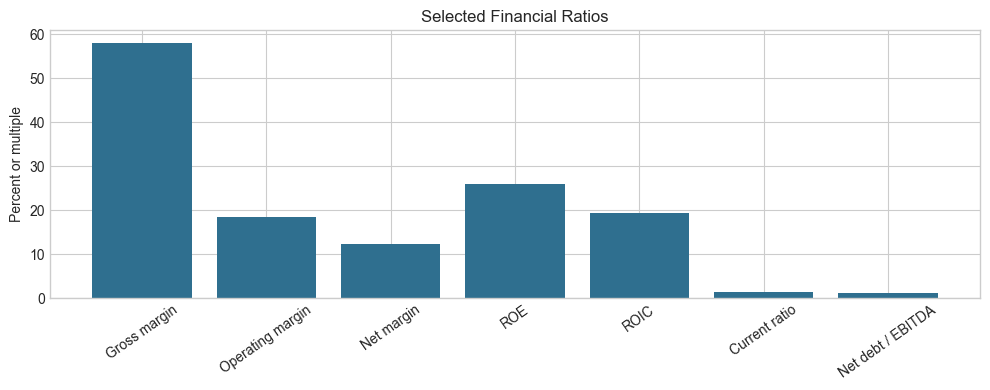

In [10]:
display_ratios = ratios.copy()
display_ratios["display_value"] = display_ratios.apply(
    lambda row: row["value"] if "ratio" in row["ratio"].lower() or "/" in row["ratio"] else row["value"] * 100,
    axis=1,
)

fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(display_ratios["ratio"], display_ratios["display_value"], color="#2f6f8f")
ax.set_title("Selected Financial Ratios")
ax.set_ylabel("Percent or multiple")
ax.tick_params(axis="x", rotation=35)
plt.tight_layout()
plt.show()

## 5. Application

Ratios are screening tools, not final answers. They help decide where to investigate next: margins explain profitability, returns explain capital efficiency, liquidity explains short-term resilience, and leverage explains financial risk.

## 6. Reflection

- Ratios make financial statements comparable across firms and time.
- Profitability and returns on capital are different but related.
- Liquidity ratios focus on near-term obligations.
- Leverage ratios show financial risk and debt capacity.

Questions to answer after running the notebook:

1. Why can a high-margin company still have poor returns on capital?
2. Why is net debt more useful than gross debt for many comparisons?
3. What does a current ratio below 1 suggest?
4. Why should ratios be compared against peers and history?